## Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing clean data

In [2]:
df = pd.read_csv('Household_clean_data.csv')
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_Name,Month_Name,Year,Hours,Minutes,Total_metering
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Saturday,December,2006,17,24,18.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,Saturday,December,2006,17,25,17.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,Saturday,December,2006,17,26,19.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,Saturday,December,2006,17,27,18.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,Saturday,December,2006,17,28,18.0


#### Checking info

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044506 entries, 0 to 1044505
Data columns (total 15 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1044506 non-null  str    
 1   Time                   1044506 non-null  str    
 2   Global_active_power    1044506 non-null  float64
 3   Global_reactive_power  1044506 non-null  float64
 4   Voltage                1044506 non-null  float64
 5   Global_intensity       1044506 non-null  float64
 6   Sub_metering_1         1044506 non-null  float64
 7   Sub_metering_2         1044506 non-null  float64
 8   Sub_metering_3         1044506 non-null  float64
 9   Day_Name               1044506 non-null  str    
 10  Month_Name             1044506 non-null  str    
 11  Year                   1044506 non-null  int64  
 12  Hours                  1044506 non-null  int64  
 13  Minutes                1044506 non-null  int64  
 14  Total_metering         104450

#### Statistical info

In [3]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Year,Hours,Minutes,Total_metering
count,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06
mean,1.108202e+00,1.182732e-01,2.399598e+02,4.718123e+00,1.177451e+00,1.475177e+00,5.933837e+00,2.007458e+03,1.150458e+01,2.949982e+01,8.586465e+00
std,1.129546e+00,1.095062e-01,3.284504e+00,4.763588e+00,6.321183e+00,6.352703e+00,8.210398e+00,5.388726e-01,6.923520e+00,1.731770e+01,1.325575e+01
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2.006000e+03,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.880000e-01,0.000000e+00,2.379700e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.007000e+03,6.000000e+00,1.500000e+01,0.000000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.007000e+03,1.200000e+01,3.000000e+01,1.000000e+00
75%,1.544000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2.008000e+03,1.800000e+01,4.400000e+01,1.800000e+01
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01,2.008000e+03,2.300000e+01,5.900000e+01,1.290000e+02


## Analysis

#### Univariate analysis

In [4]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Day_Name', 'Month_Name', 'Year', 'Hours', 'Minutes',
       'Total_metering'],
      dtype='str')

###### Checking the distribution for 'Global_active_power', 'Global_reactive_power','Voltage', 'Global_intensity','Total_metering'

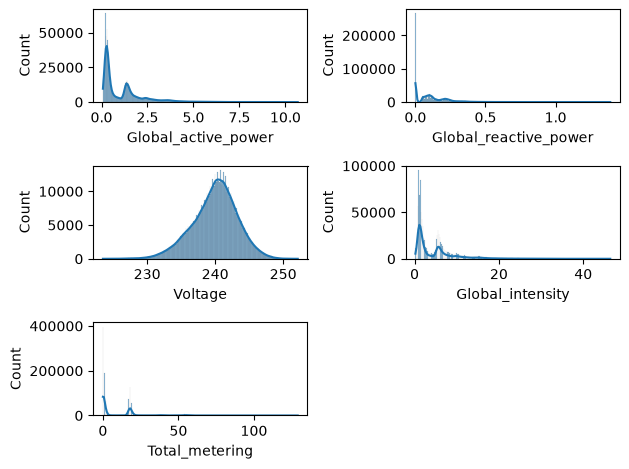

In [5]:
pos=1
hist = ['Global_active_power', 'Global_reactive_power','Voltage', 'Global_intensity','Total_metering']
for i in hist:
    plt.subplot(3,2,pos)
    sns.histplot(df[i],kde=True) #KDE: Kernel density estimator
    pos+=1
plt.tight_layout()
plt.show() 

#### Bivariate analysis

##### Year,month_name,dayname and hour wise total consumption

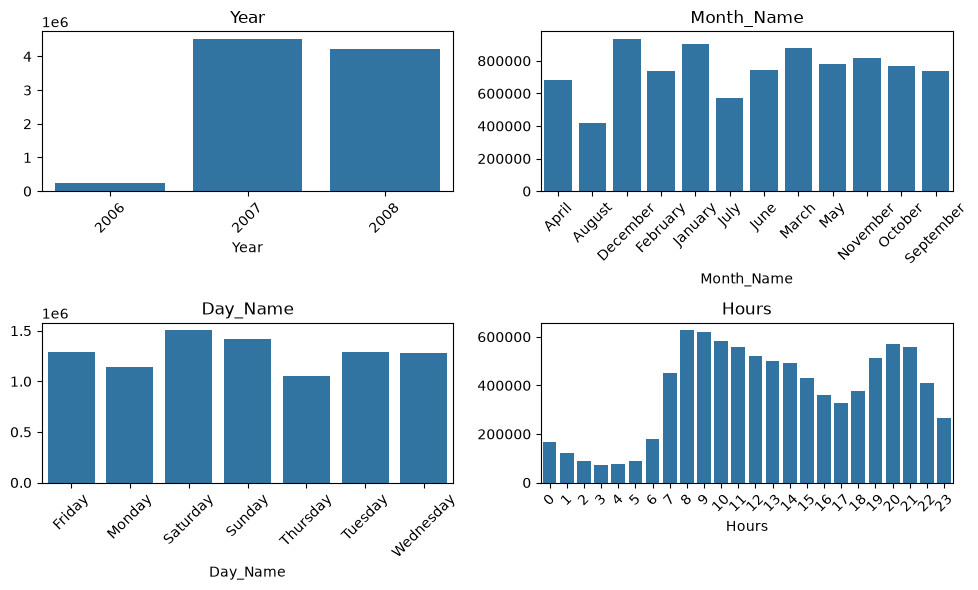

In [6]:
plt.figure(figsize=(10,6))
pos=1
cat_2 = ['Year', 'Month_Name','Day_Name', 'Hours']
for i in cat_2:
    plt.subplot(2,2,pos)
    x = df.groupby(i)['Total_metering'].sum().index
    y = df.groupby(i)['Total_metering'].sum().values
    sns.barplot(x=x,y=y) 
    pos+=1
    plt.xticks(rotation = 45)
    plt.title(i)
plt.tight_layout()
plt.show() 

##### Year,month_name,dayname and hour wise Global_active_power

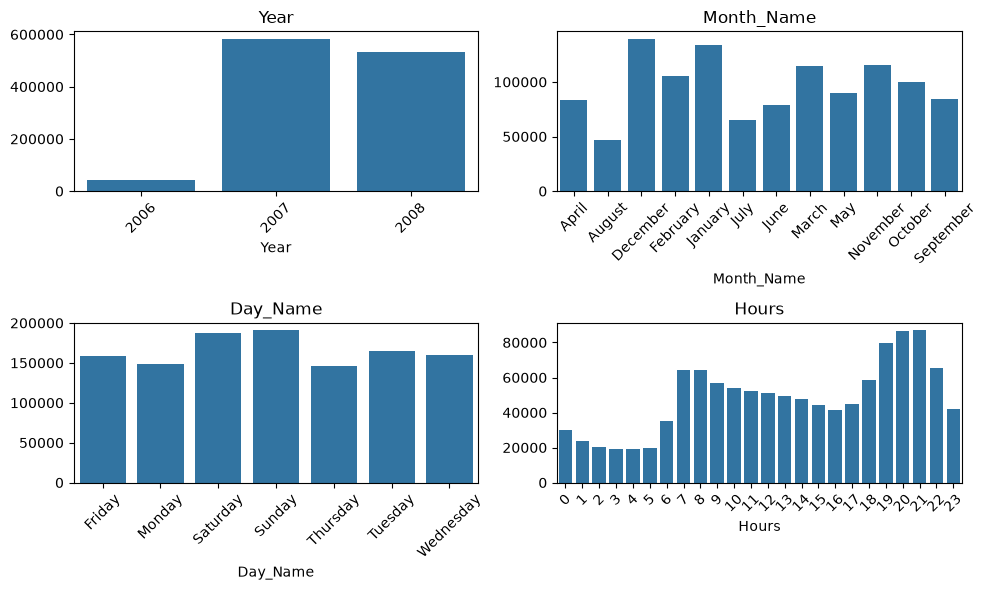

In [7]:
plt.figure(figsize=(10,6))
pos=1
cat_2 = ['Year', 'Month_Name','Day_Name', 'Hours']
for i in cat_2:
    plt.subplot(2,2,pos)
    x = df.groupby(i)['Global_active_power'].sum().index
    y = df.groupby(i)['Global_active_power'].sum().values
    sns.barplot(x=x,y=y) 
    pos+=1
    plt.xticks(rotation = 45)
    plt.title(i)
plt.tight_layout()
plt.show() 

##### Year,month_name,dayname and hour wise Global_reactive_power

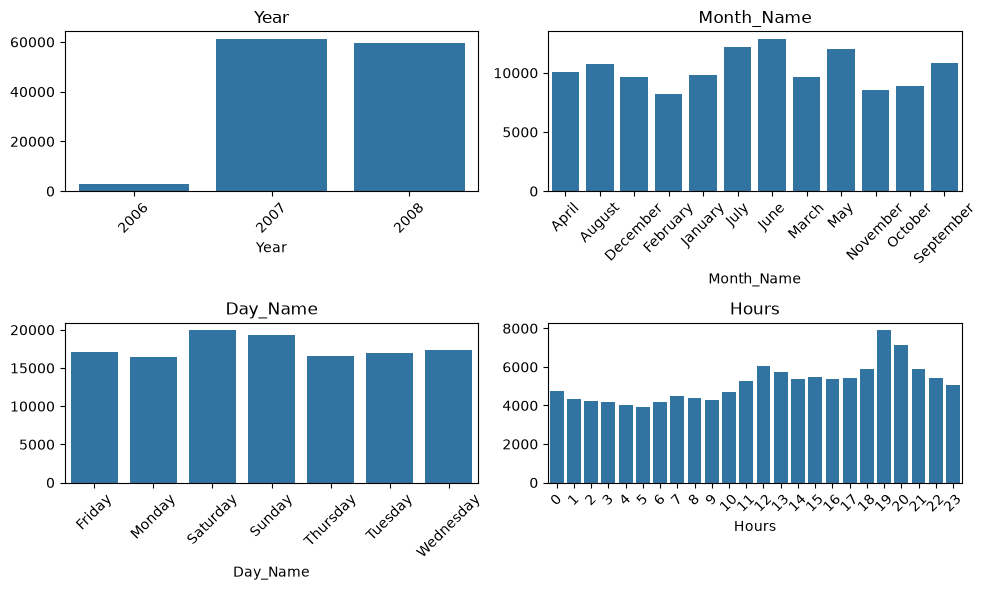

In [8]:
plt.figure(figsize=(10,6))
pos=1
cat_2 = ['Year', 'Month_Name','Day_Name', 'Hours']
for i in cat_2:
    plt.subplot(2,2,pos)
    x = df.groupby(i)['Global_reactive_power'].sum().index
    y = df.groupby(i)['Global_reactive_power'].sum().values
    sns.barplot(x=x,y=y) 
    pos+=1
    plt.xticks(rotation = 45)
    plt.title(i)
plt.tight_layout()
plt.show() 

##### Year,month_name,dayname and hour wise Voltage

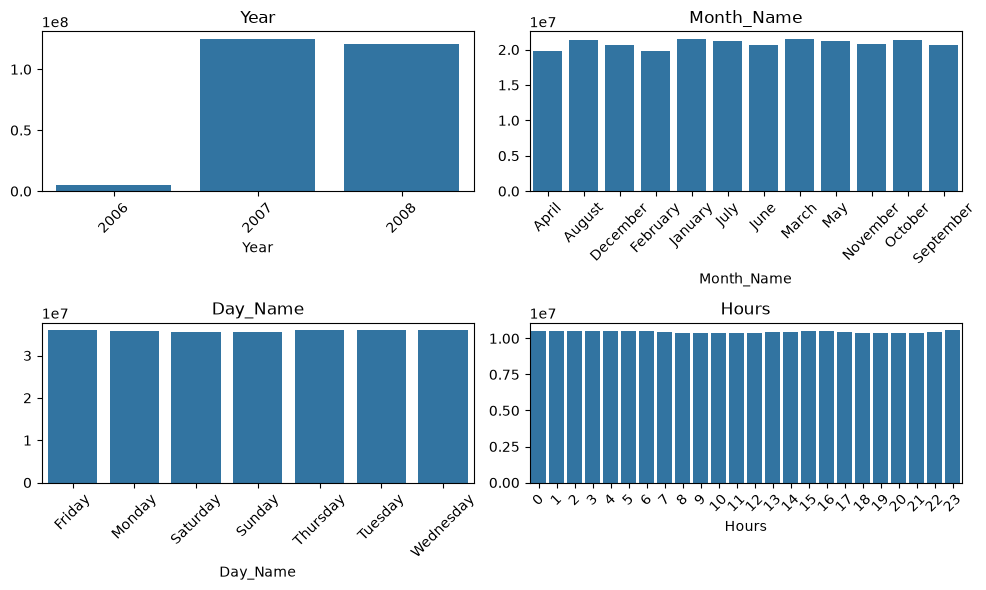

In [9]:
plt.figure(figsize=(10,6))
pos=1
cat_2 = ['Year', 'Month_Name','Day_Name', 'Hours']
for i in cat_2:
    plt.subplot(2,2,pos)
    x = df.groupby(i)['Voltage'].sum().index
    y = df.groupby(i)['Voltage'].sum().values
    sns.barplot(x=x,y=y) 
    pos+=1
    plt.xticks(rotation = 45)
    plt.title(i)
plt.tight_layout()
plt.show() 

# Bar labels

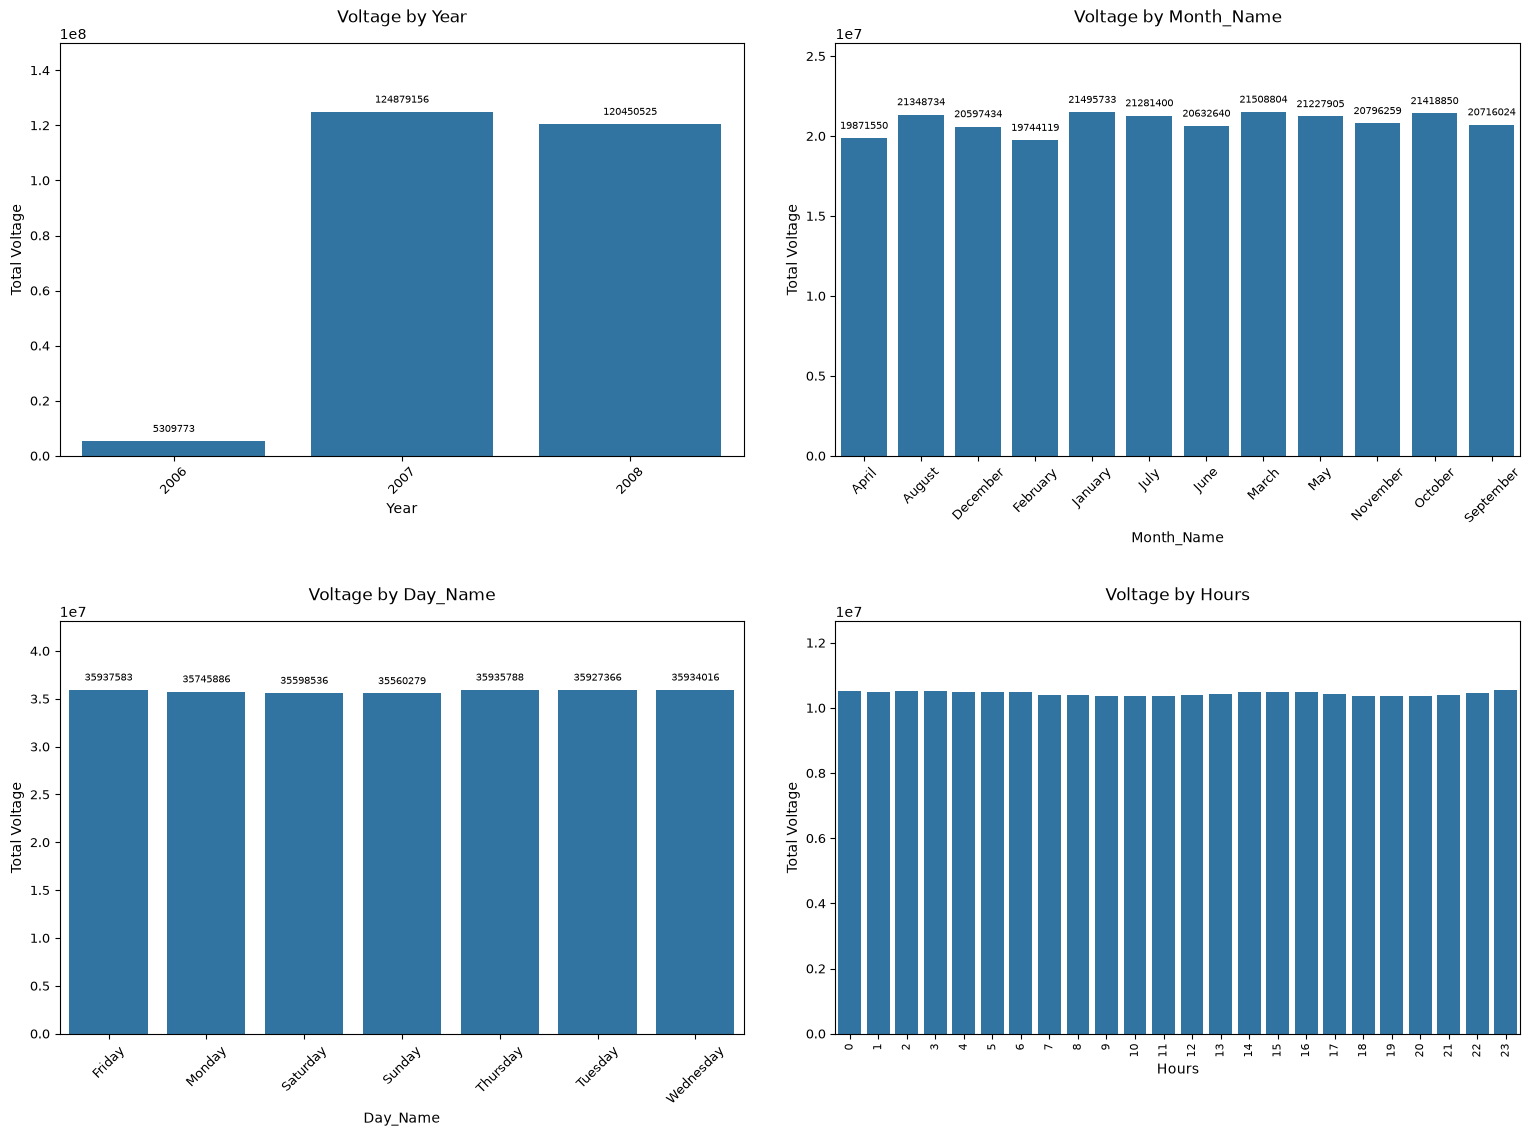

In [18]:
plt.figure(figsize=(16, 12))

cat_2 = ['Year', 'Month_Name', 'Day_Name', 'Hours']

for pos, i in enumerate(cat_2, 1):

    ax = plt.subplot(2, 2, pos)

    data = df.groupby(i)['Voltage'].sum()

    sns.barplot(x=data.index, y=data.values, ax=ax)

    # Add space above bars
    ax.set_ylim(0, data.max() * 1.20)

    # Bar labels
    if i != 'Hours':
        ax.bar_label(
            ax.containers[0],
            fmt='%.0f',
            padding=5,
            fontsize=7
        )

    # X-axis labels
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # Hours → vertical labels
    if i == 'Hours':
        ax.tick_params(axis='x', rotation=90, labelsize=8)

    # Y-axis labels
    ax.tick_params(axis='y', rotation=0, labelsize=9)

    ax.set_xlabel(i)
    ax.set_ylabel('Total Voltage')

    ax.set_title(
        f'Voltage by {i}',
        fontsize=12,
        pad=15
    )

plt.tight_layout(pad=3)
plt.show()

In [19]:
df.head(1)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_Name,Month_Name,Year,Hours,Minutes,Total_metering
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Saturday,December,2006,17,24,18.0
